In [1]:
import os
import numpy as np 

from noah2 import data as D
from causalflow import causalflow

In [2]:
# --- plotting ---
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rcParams['text.usetex'] = True
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['axes.linewidth'] = 1.5
mpl.rcParams['axes.xmargin'] = 1
mpl.rcParams['xtick.labelsize'] = 'x-large'
mpl.rcParams['xtick.major.size'] = 5
mpl.rcParams['xtick.major.width'] = 1.5
mpl.rcParams['ytick.labelsize'] = 'x-large'
mpl.rcParams['ytick.major.size'] = 5
mpl.rcParams['ytick.major.width'] = 1.5
mpl.rcParams['legend.frameon'] = False

# load test data

In [3]:
##################################################################
# read CRS participant data
DNoah = D.Noah2()
fema = DNoah._read_data_full()
is_participant = DNoah._participants(fema)
fema = fema[is_participant]

metro = ((fema['RUCA1'] == 1))# | (fema['RUCA1'] == 2) | (fema['RUCA1'] == 3))
micro = ((fema['RUCA1'] == 4) | (fema['RUCA1'] == 5) | (fema['RUCA1'] == 6))
small = ((fema['RUCA1'] == 7) | (fema['RUCA1'] == 8) | (fema['RUCA1'] == 9))
rural = ((fema['RUCA1'] == 10))

columns = DNoah._columns()[:8] + ['s_%s' % c for c in ['c350', 'c420', 'c450']]
column_labels = np.array(DNoah._column_labels()[:8] + ['c350', 'c420', 'c450'])

# binary activity codes
binary_activities = ['c360', 'c520', 'c530', 'c540', 'c610', 'c620', 'c630']

binary_data = np.array([np.array(fema[col]) for col in binary_activities]).T
binary_data = (binary_data > 0).astype(int)

binary_act_codes = np.zeros(len(fema)).astype(int)
for i in range(binary_data.shape[1]):
    binary_act_codes += 2**i * binary_data[:,i]

# compile training data
_data = np.array([np.array(fema[col]) for col in columns]).T
# reduce dynamical range
_data[:,0] = np.log10(_data[:,0])
_data[:,3] = np.log10(_data[:,3])
_data[:,4] = np.log10(_data[:,4])

# test flows for different archetype + binary activity combo

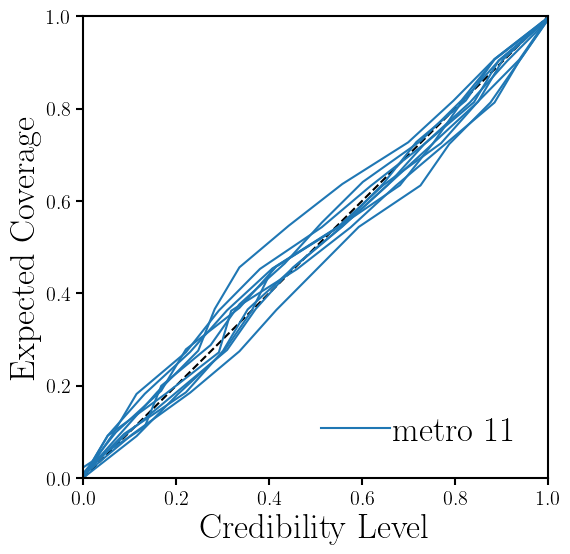

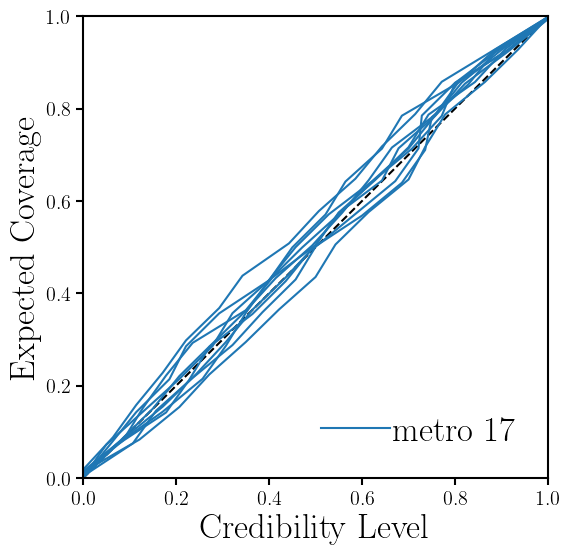

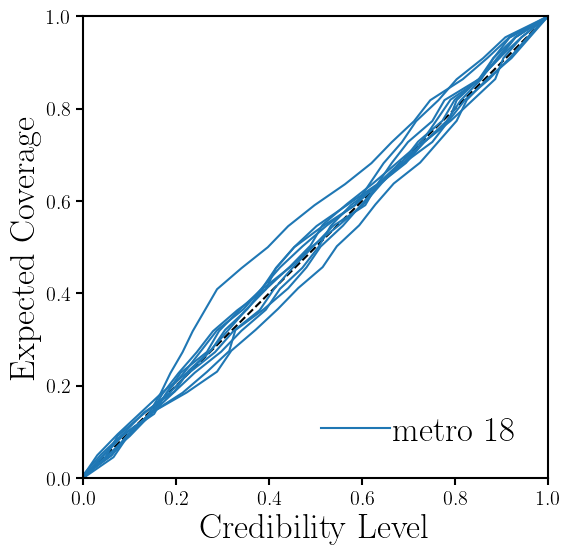

In [ ]:
arch = 'metro'
#for code in [0, 1, 2, 3, 8, 9, 10, 11, 17, 18, 24, 25, 27, 29, 31, 64, 66, 67, 72, 73, 75, 91, 95]: 
for code in [11, 17, 18, 24, 25, 27, 29, 31, 64, 66, 67, 72, 73, 75, 91, 95]: 
    study_name = '%s.%i' % (arch, code)
    study_dir = '/scratch/gpfs/chhahn/noah/noah2/qphi/'
    
    if not os.path.isdir('%s%s' % (study_dir, study_name)): 
        print('%s.%i does not exist' % (arch, code))
        continue
    
    # only keep data of specified archetype that performs set of binary activities
    arch_dict = {'metro': metro, 'micro': micro, 'small': small, 'rural': rural}    
    test_data = _data[arch_dict[arch] & (binary_act_codes == code)]

    Ntrain = int(test_data.shape[0] * 0.9)

    # shufftle training data
    ishfl = np.arange(test_data.shape[0])
    np.random.seed(42)
    np.random.shuffle(ishfl)
    test_data = test_data[ishfl][Ntrain:] # reserve 10% for testing
    
    Cflow = causalflow.CausalFlowA()

    flows = Cflow._load_flows_optuna(study_name, study_dir)
        
    fig, ax = plt.subplots(1, 1, figsize=(6,6))
    ax.plot([0, 1], [0, 1], ls="--", color="k")
    for ii in range(10): 
        alpha, ecp = Cflow._validate(flows, test_data[:,1:], test_data[:,0][:,None], Nsample=10000, verbose=False)
        if ii == 0: ax.plot(alpha, ecp, color='C0', label='%s %i' % (arch, code)) 
        else: ax.plot(alpha, ecp, color='C0')
    ax.legend(loc='lower right', handletextpad=0.1, fontsize=25)
    ax.set_ylabel("Expected Coverage", fontsize=25)
    ax.set_ylim(0., 1.)
    ax.set_xlabel("Credibility Level", fontsize=25)
    ax.set_xlim(0., 1.)
    plt.show()
    plt.close()

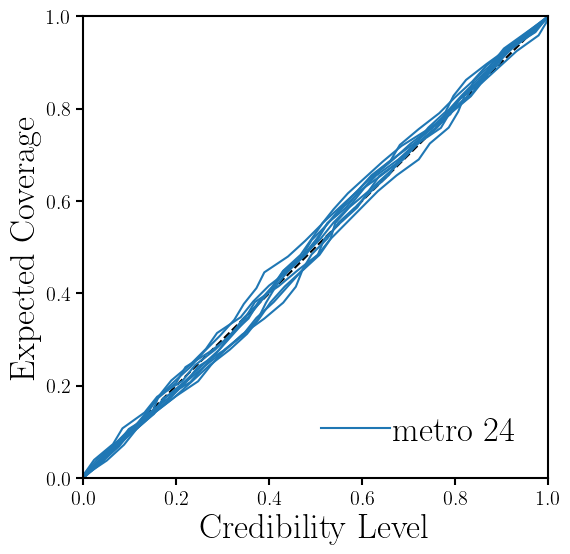

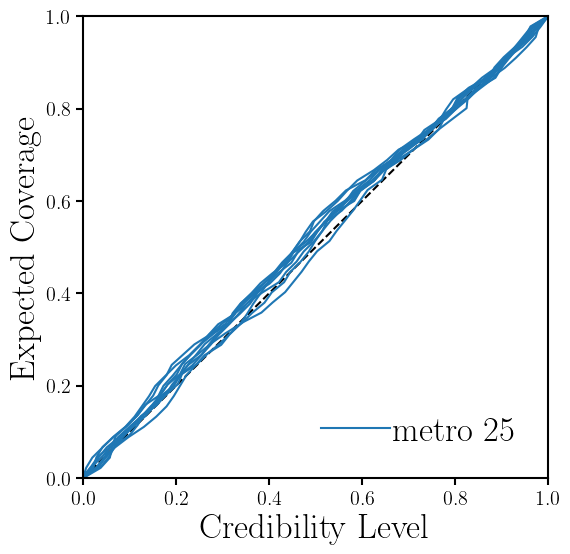

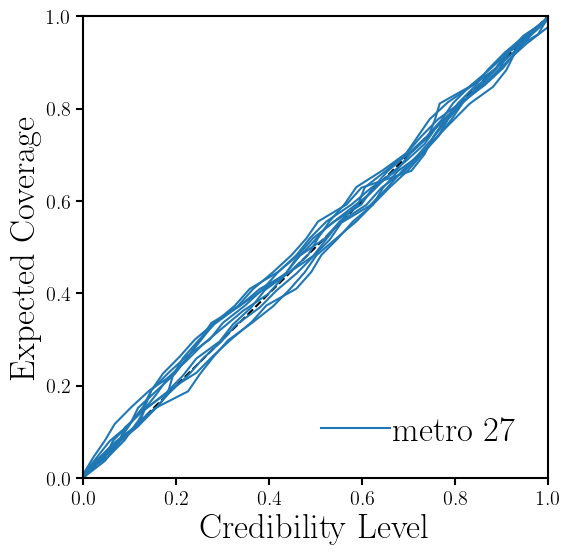

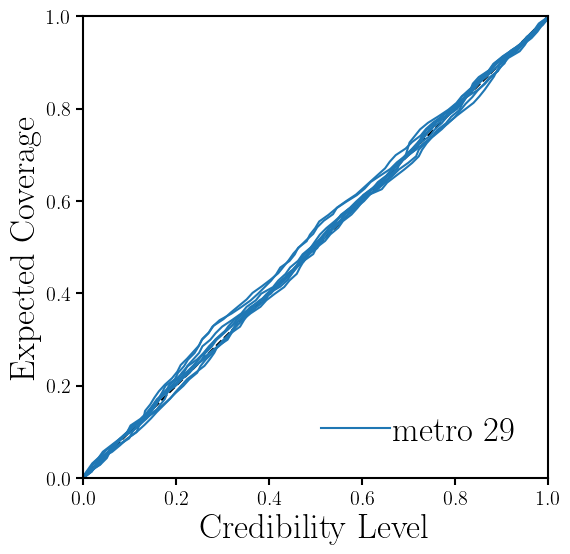

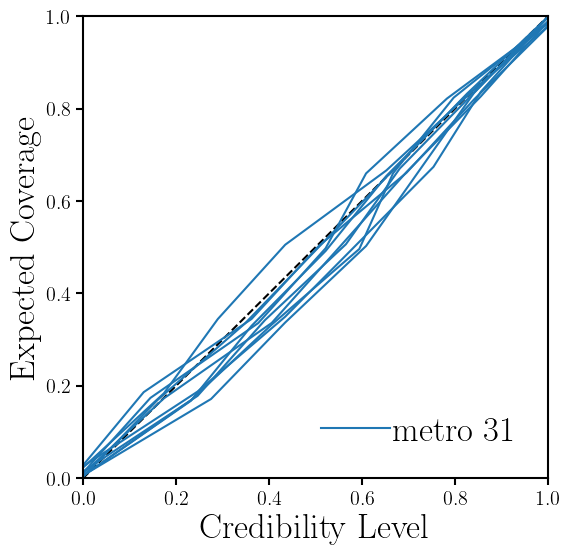

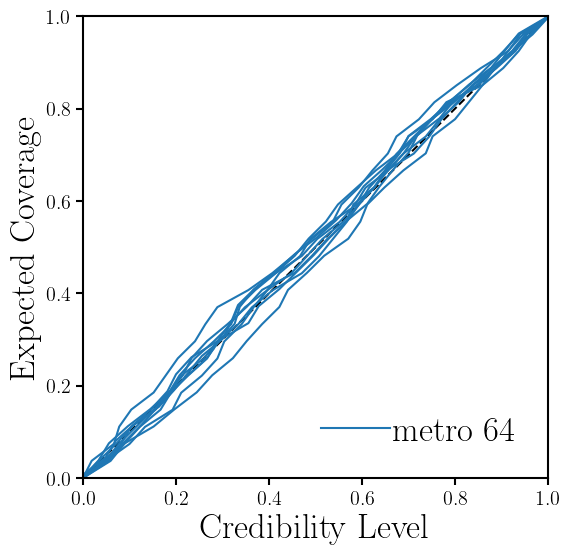

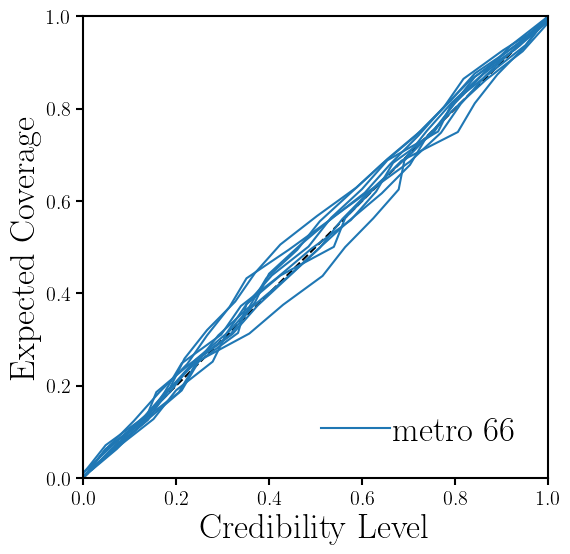

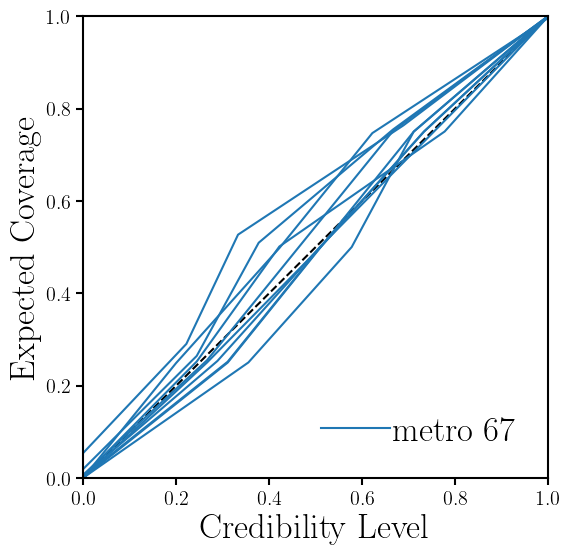

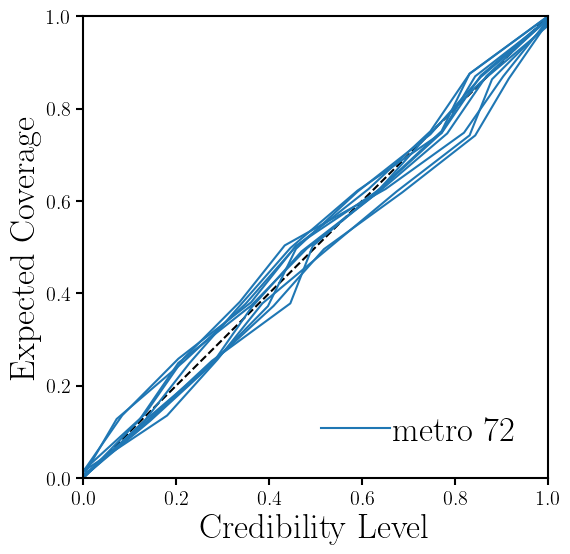

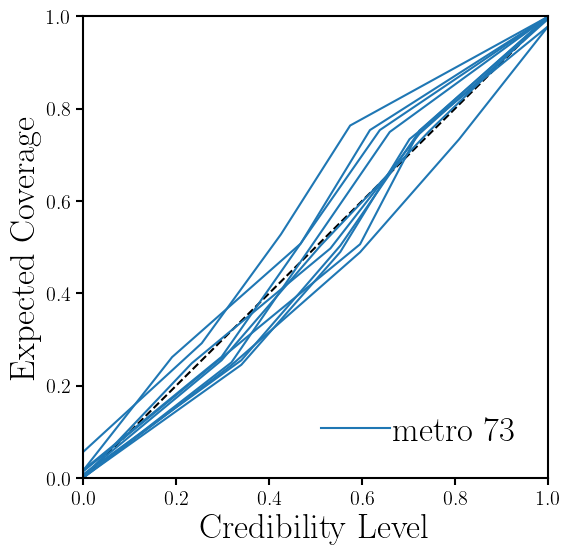

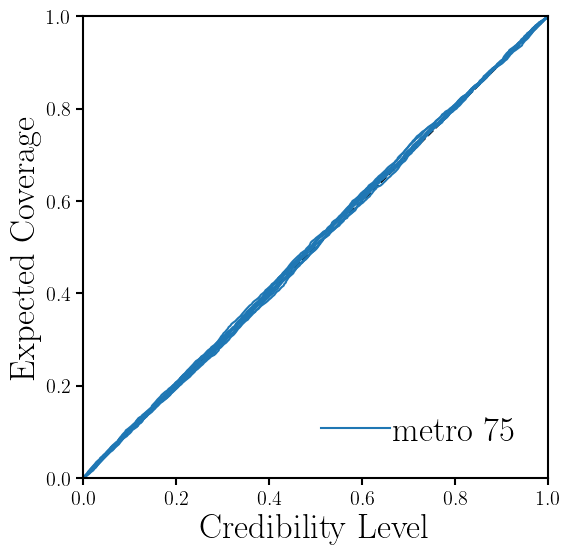

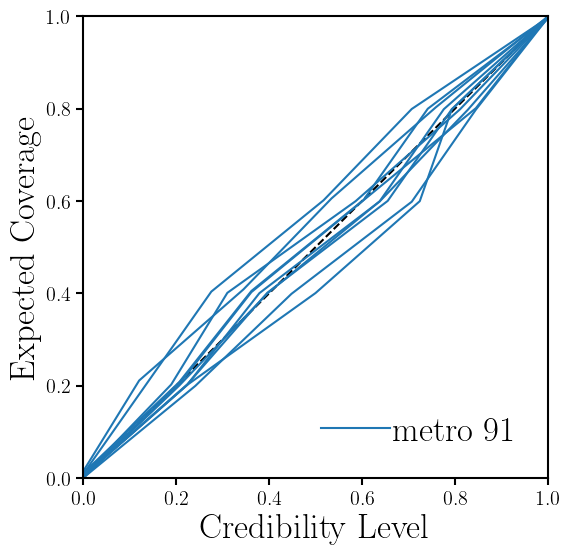

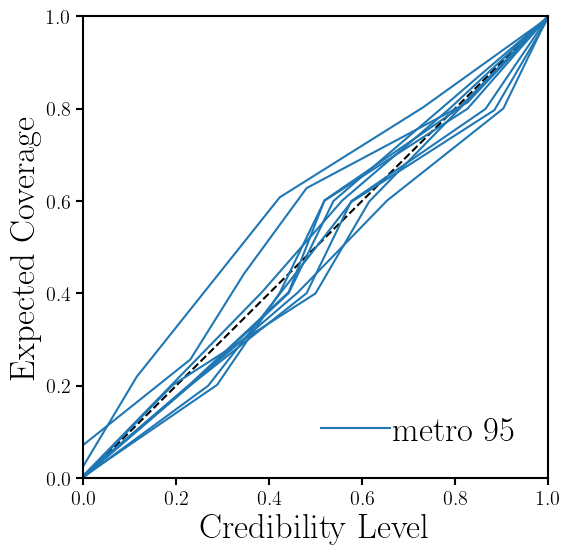

In [4]:
arch = 'metro'
#for code in [0, 1, 2, 3, 8, 9, 10, 11, 17, 18, 24, 25, 27, 29, 31, 64, 66, 67, 72, 73, 75, 91, 95]: 
for code in [24, 25, 27, 29, 31, 64, 66, 67, 72, 73, 75, 91, 95]: 
    study_name = '%s.%i' % (arch, code)
    study_dir = '/scratch/gpfs/chhahn/noah/noah2/qphi/'
    
    if not os.path.isdir('%s%s' % (study_dir, study_name)): 
        print('%s.%i does not exist' % (arch, code))
        continue
    
    # only keep data of specified archetype that performs set of binary activities
    arch_dict = {'metro': metro, 'micro': micro, 'small': small, 'rural': rural}    
    test_data = _data[arch_dict[arch] & (binary_act_codes == code)]

    Ntrain = int(test_data.shape[0] * 0.9)

    # shufftle training data
    ishfl = np.arange(test_data.shape[0])
    np.random.seed(42)
    np.random.shuffle(ishfl)
    test_data = test_data[ishfl][Ntrain:] # reserve 10% for testing
    
    Cflow = causalflow.CausalFlowA()

    flows = Cflow._load_flows_optuna(study_name, study_dir)
        
    fig, ax = plt.subplots(1, 1, figsize=(6,6))
    ax.plot([0, 1], [0, 1], ls="--", color="k")
    for ii in range(10): 
        alpha, ecp = Cflow._validate(flows, test_data[:,1:], test_data[:,0][:,None], Nsample=10000, verbose=False)
        if ii == 0: ax.plot(alpha, ecp, color='C0', label='%s %i' % (arch, code)) 
        else: ax.plot(alpha, ecp, color='C0')
    ax.legend(loc='lower right', handletextpad=0.1, fontsize=25)
    ax.set_ylabel("Expected Coverage", fontsize=25)
    ax.set_ylim(0., 1.)
    ax.set_xlabel("Credibility Level", fontsize=25)
    ax.set_xlim(0., 1.)
    plt.show()
    plt.close()

Test Sample:   0%|          | 0/381 [00:00<?, ?it/s]

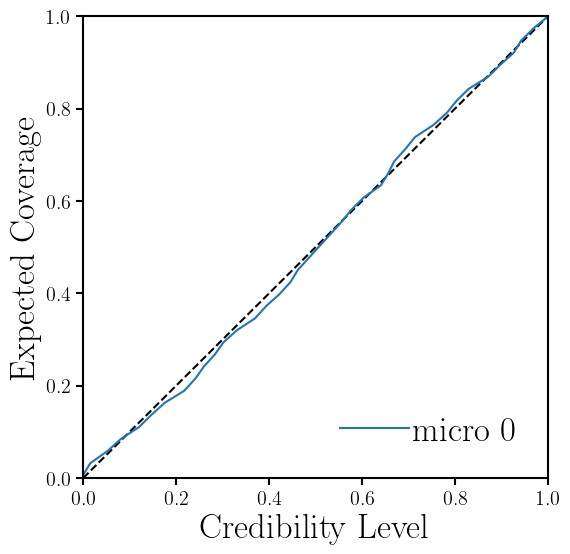

Test Sample:   0%|          | 0/50 [00:00<?, ?it/s]

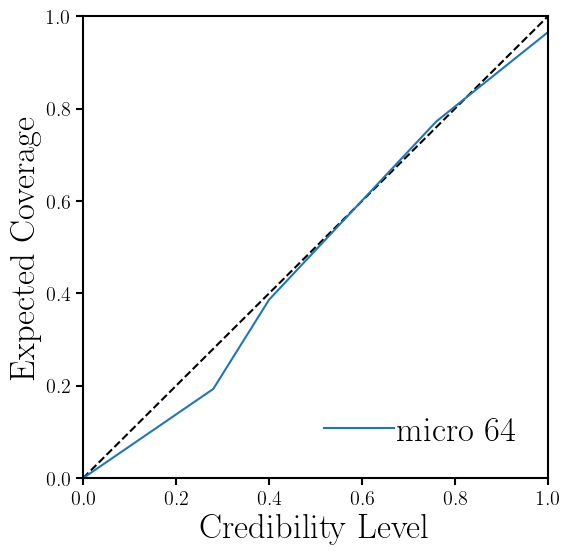

In [10]:
arch = 'micro'
for code in [0, 64]: 
    # only keep data of specified archetype that performs set of binary activities
    arch_dict = {'metro': metro, 'micro': micro, 'small': small, 'rural': rural}    
    test_data = _data[arch_dict[arch] & (binary_act_codes == code)]

    Ntrain = int(test_data.shape[0] * 0.9)

    # shufftle training data
    ishfl = np.arange(test_data.shape[0])
    np.random.seed(42)
    np.random.shuffle(ishfl)
    test_data = test_data[ishfl][Ntrain:] # reserve 10% for testing
    
    Cflow = causalflow.CausalFlowA()
    study_name = '%s.%i' % (arch, code)
    study_dir = '/scratch/gpfs/chhahn/noah/noah2/qphi/'

    flows = Cflow._load_flows_optuna(study_name, study_dir)

    fig, ax = plt.subplots(1, 1, figsize=(6,6))
    
    ax.plot([0, 1], [0, 1], ls="--", color="k")
    for ii in range(10): 
        alpha, ecp = Cflow._validate(flows, test_data[:,1:], test_data[:,0][:,None], Nsample=10000, verbose=True)
        if ii == 0: ax.plot(alpha, ecp, color='C0', label='%s %i' % (arch, code)) 
        else: ax.plot(alpha, ecp, color='C0')
            
    ax.legend(loc='lower right', handletextpad=0.1, fontsize=25)
    ax.set_ylabel("Expected Coverage", fontsize=25)
    ax.set_ylim(0., 1.)
    ax.set_xlabel("Credibility Level", fontsize=25)
    ax.set_xlim(0., 1.)
    plt.show()